
# Clean notebook: real-image frame candidate search for corridor animation

This notebook searches for **candidate nuclei** that can later be assembled into a corridor-migration animation, using the **native background + DAPI alignment already present in the dataset**.

## What this notebook does
- loads the metadata CSV
- parses `pseudotime`, `pseudotime_widths`, and `pseudotime_center_bin`
- converts each object into a **full ordered width profile** across one corridor period
- builds **20 frame templates**
- scores every object against every frame
- previews candidates using the **real background + DAPI overlay**
- exports grouped candidate folders, metadata CSVs, and contact sheets

## Important design choice
This notebook does **not** synthesize a new corridor projection.  
It uses the **real registered images** from `path_background` and `path_dapi`, which avoids the misalignment problem.

## Expected inputs
The CSV should contain at least:
- `path_background`
- `path_dapi`
- `pseudotime`
- `pseudotime_widths`
- `pseudotime_center_bin`

Optional but useful:
- `dapi_ImageNumber`
- `ObjectNumber`

## Output
A folder structure like:

```text
frame_candidate_search_output/
  f01_entry_10/
    metadata.csv
    candidate_0001_img....png
    candidate_0002_img....png
    contact_sheet_001.png
  ...
  summary_counts.csv
  summary_best_candidates.csv
```


In [1]:

from pathlib import Path
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile

from IPython.display import display


# ----------------------------
# USER CONFIG
# ----------------------------
CSV_PATH = Path("datasets\combined_clustered_data 1462.csv")
OUT_DIR = Path("frame_candidate_search_output")

BG_COL = "path_background"
DAPI_COL = "path_dapi"

PT_BINS_COL = "pseudotime"
PT_WIDTHS_COL = "pseudotime_widths"
PT_CENTER_COL = "pseudotime_center_bin"

IMAGE_NUM_COL = "dapi_ImageNumber"
OBJECT_NUM_COL = "ObjectNumber"

N_PROFILE = 100          # resampled profile length used for scoring
TOP_K_PER_FRAME = 50     # set to None to export all candidates
ROWS_PER_CONTACT_SHEET = 10

# display settings for overlays
BF_WEIGHT = 0.35
DAPI_GAIN = 4.0
DAPI_FIXED_MAX = 160.0
INVERT_BF = True

# crop settings for candidate previews
CROP_THR = 0.15
CROP_PAD = 25

# score weights
W_EMD = 0.50
W_COM = 0.30
W_L2 = 0.20
assert abs((W_EMD + W_COM + W_L2) - 1.0) < 1e-9


In [2]:

# ----------------------------
# PARSING + BASIC HELPERS
# ----------------------------
def parse_vec(x, dtype=float):
    if isinstance(x, np.ndarray):
        return x.astype(dtype)
    if isinstance(x, list):
        return np.asarray(x, dtype=dtype)
    if pd.isna(x):
        return np.array([], dtype=dtype)

    s = str(x).replace("[", " ").replace("]", " ").replace(",", " ").strip()
    if not s:
        return np.array([], dtype=dtype)

    parts = [p for p in s.split() if p]
    return np.asarray(parts, dtype=dtype)


def build_unique_key(row):
    img_num = row.get(IMAGE_NUM_COL, np.nan)
    obj_num = row.get(OBJECT_NUM_COL, np.nan)

    if pd.notna(img_num) and pd.notna(obj_num):
        return f"img{int(img_num):05d}_obj{int(obj_num):05d}"

    stem = Path(str(row.get(DAPI_COL, "missing_dapi"))).stem
    if pd.notna(obj_num):
        return f"{stem}_obj{int(obj_num):05d}"
    return stem


def resolve_existing_path(path_str):
    p = Path(path_str)
    if p.exists():
        return p

    # fallback: same filename in current working directory
    p2 = Path(p.name)
    if p2.exists():
        return p2

    return p


def read_image(path):
    return tifffile.imread(str(resolve_existing_path(path)))


def to_2d(img):
    img = np.asarray(img)
    if img.ndim == 2:
        return img
    if img.ndim == 3:
        if img.shape[0] == 1:
            return img[0]
        if img.shape[-1] == 1:
            return img[..., 0]
        return img[0] if img.shape[0] <= 4 else img[..., 0]
    raise ValueError(f"Unsupported image shape: {img.shape}")


def normalize_percentile(img, pmin=1, pmax=99):
    img = np.asarray(img, dtype=np.float32)
    lo = np.percentile(img, pmin)
    hi = np.percentile(img, pmax)
    if hi <= lo:
        return np.zeros_like(img, dtype=np.float32)
    return np.clip((img - lo) / (hi - lo), 0, 1)


def scale_dapi_fixed(dapi, fixed_max=160.0):
    dapi = np.asarray(dapi, dtype=np.float32)
    if fixed_max <= 0:
        raise ValueError("fixed_max must be > 0")
    return np.clip(dapi / fixed_max, 0, 1)


def make_overlay_fixed_dapi(
    bg,
    dapi,
    bf_weight=0.35,
    dapi_gain=4.0,
    invert_bf=True,
    dapi_fixed_max=160.0
):
    bg_norm = normalize_percentile(bg, 1, 99)

    if invert_bf:
        bg_norm = 1.0 - bg_norm

    dapi_disp = scale_dapi_fixed(dapi, fixed_max=dapi_fixed_max)
    dapi_enh = np.clip(dapi_disp * dapi_gain, 0, 1)

    rgb = np.zeros((*bg.shape, 3), dtype=np.float32)
    rgb[..., 0] = bg_norm * bf_weight
    rgb[..., 1] = bg_norm * bf_weight
    rgb[..., 2] = bg_norm * bf_weight

    rgb[..., 2] += dapi_enh
    rgb[..., 1] += dapi_enh * 0.15
    rgb[..., 0] += dapi_enh * 0.05
    rgb = np.clip(rgb, 0, 1)

    return rgb, dapi_disp, dapi_enh


def crop_from_signal(img, signal, thr=0.15, pad=25):
    mask = signal > thr
    ys, xs = np.where(mask)

    if len(xs) == 0:
        return img

    y0 = max(int(ys.min()) - pad, 0)
    y1 = min(int(ys.max()) + pad + 1, img.shape[0])
    x0 = max(int(xs.min()) - pad, 0)
    x1 = min(int(xs.max()) + pad + 1, img.shape[1])

    return img[y0:y1, x0:x1]


def linearize_profile(pt_bins, pt_widths, period_len):
    '''
    Build a full left-to-right profile with one slot per pseudotime bin.
    Missing bins are filled with zero.
    '''
    v = np.zeros(period_len, dtype=float)

    pt_bins = np.asarray(pt_bins, dtype=int)
    pt_widths = np.asarray(pt_widths, dtype=float)

    if len(pt_bins) == 0 or len(pt_widths) == 0 or len(pt_bins) != len(pt_widths):
        return v

    for b, w in zip(pt_bins, pt_widths):
        if 0 <= int(b) < period_len:
            v[int(b)] = float(w)

    return v


def centered_profile(linear_profile, center_bin):
    '''
    Rotate a full profile so that center_bin sits in the middle.
    Used for diagnostic plotting only.
    '''
    v = np.asarray(linear_profile, dtype=float)
    if len(v) == 0:
        return v

    center_bin = int(center_bin) if pd.notna(center_bin) else 0
    shift = len(v) // 2 - center_bin
    return np.roll(v, shift)


def resample_profile(v, n=100):
    v = np.asarray(v, dtype=float)
    if len(v) == 0:
        return np.zeros(n, dtype=float)
    if len(v) == 1:
        return np.repeat(v[0], n).astype(float)

    x_old = np.linspace(0, 1, len(v))
    x_new = np.linspace(0, 1, n)
    return np.interp(x_new, x_old, v)


def normalize_profile(v):
    v = np.asarray(v, dtype=float)
    v = np.clip(v, 0, None)
    s = v.sum()
    if s <= 0:
        return np.zeros_like(v, dtype=float)
    return v / s


def profile_center_of_mass(v):
    p = normalize_profile(v)
    if p.sum() <= 0:
        return np.nan
    x = np.linspace(0, 1, len(p))
    return float((x * p).sum())


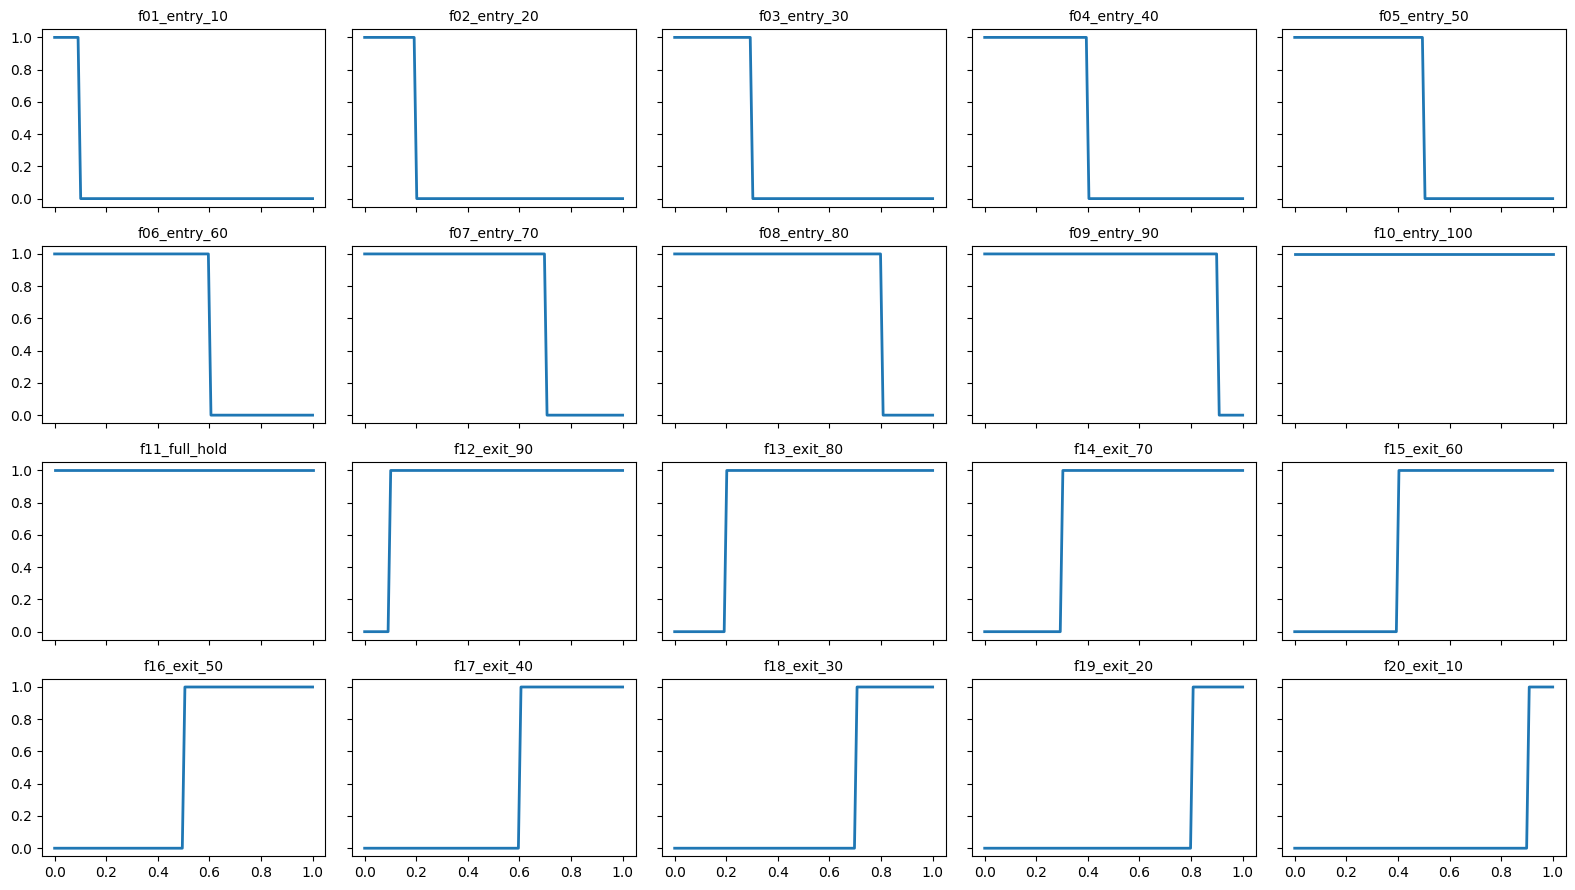

In [3]:

# ----------------------------
# FRAME TEMPLATES + SCORING
# ----------------------------
def make_20_frame_templates(n=100):
    '''
    20 total frames:
    10 entry-like frames
    1 full hold frame
    9 exit-like frames
    '''
    templates = []

    # entry: [0, 0.1] ... [0, 1.0]
    for i in range(1, 11):
        frac = i / 10.0
        t = np.zeros(n, dtype=float)
        t[:max(1, int(round(frac * n)))] = 1.0
        templates.append({
            "frame_idx": i,
            "frame_name": f"f{i:02d}_entry_{int(frac*100):02d}",
            "frame_kind": "entry",
            "start_frac": 0.0,
            "end_frac": frac,
            "template": t,
        })

    # full hold
    templates.append({
        "frame_idx": 11,
        "frame_name": "f11_full_hold",
        "frame_kind": "hold",
        "start_frac": 0.0,
        "end_frac": 1.0,
        "template": np.ones(n, dtype=float),
    })

    # exit: [0.1, 1.0] ... [0.9, 1.0]
    for j, frac in enumerate(np.arange(0.1, 1.0, 0.1), start=12):
        t = np.ones(n, dtype=float)
        t[:int(round(frac * n))] = 0.0
        remain = int(round((1.0 - frac) * 100))

        templates.append({
            "frame_idx": j,
            "frame_name": f"f{j:02d}_exit_{remain:02d}",
            "frame_kind": "exit",
            "start_frac": float(frac),
            "end_frac": 1.0,
            "template": t,
        })

    return templates


FRAME_TEMPLATES = make_20_frame_templates(n=N_PROFILE)


def score_profile_against_template(profile_100, template_100):
    '''
    Lower score = better match.
    Uses a mix of:
    - cumulative distribution mismatch (EMD-like)
    - center-of-mass mismatch
    - direct L2 mismatch
    '''
    p = normalize_profile(profile_100)
    t = normalize_profile(template_100)

    if p.sum() <= 0 or t.sum() <= 0:
        return np.nan, np.nan, np.nan, np.nan

    cdf_p = np.cumsum(p)
    cdf_t = np.cumsum(t)

    emd_like = float(np.mean(np.abs(cdf_p - cdf_t)))
    com_dist = float(abs(profile_center_of_mass(p) - profile_center_of_mass(t)))
    l2_dist = float(np.linalg.norm(p - t))

    score = W_EMD * emd_like + W_COM * com_dist + W_L2 * l2_dist
    return score, emd_like, com_dist, l2_dist


def plot_frame_templates():
    fig, axes = plt.subplots(4, 5, figsize=(16, 9), sharex=True, sharey=True)
    axes = axes.ravel()

    x = np.linspace(0, 1, N_PROFILE)

    for ax, spec in zip(axes, FRAME_TEMPLATES):
        ax.plot(x, spec["template"], linewidth=2)
        ax.set_title(spec["frame_name"], fontsize=10)
        ax.set_ylim(-0.05, 1.05)

    for ax in axes[len(FRAME_TEMPLATES):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


plot_frame_templates()


In [4]:

# ----------------------------
# LOAD METADATA + PREPARE PROFILES
# ----------------------------
df = pd.read_csv(CSV_PATH).copy()

df["pt_bins_arr"] = df[PT_BINS_COL].apply(lambda x: parse_vec(x, dtype=int))
df["pt_widths_arr"] = df[PT_WIDTHS_COL].apply(lambda x: parse_vec(x, dtype=float))
df["pt_center_bin_num"] = pd.to_numeric(df[PT_CENTER_COL], errors="coerce")
df["unique_key"] = df.apply(build_unique_key, axis=1)

df["vec_len_match"] = df["pt_bins_arr"].apply(len) == df["pt_widths_arr"].apply(len)

# determine period length from observed max bin
PERIOD_LENGTH = int(df["pt_bins_arr"].apply(lambda a: a.max() if len(a) else -1).max() + 1)

df["linear_profile"] = df.apply(
    lambda r: linearize_profile(r["pt_bins_arr"], r["pt_widths_arr"], PERIOD_LENGTH),
    axis=1,
)
df["centered_profile"] = df.apply(
    lambda r: centered_profile(r["linear_profile"], r["pt_center_bin_num"]),
    axis=1,
)
df["profile_100"] = df["linear_profile"].apply(lambda v: resample_profile(v, n=N_PROFILE))
df["profile_100_norm"] = df["profile_100"].apply(normalize_profile)
df["profile_com"] = df["profile_100_norm"].apply(profile_center_of_mass)

print("Rows:", len(df))
print("Period length:", PERIOD_LENGTH)
print("Vector length matches:", int(df["vec_len_match"].sum()), "/", len(df))
print("Unique objects:", df["unique_key"].nunique())

display(
    df[[
        "unique_key",
        BG_COL,
        DAPI_COL,
        PT_CENTER_COL,
        "vec_len_match",
        "profile_com",
    ]].head()
)


Rows: 414
Period length: 17
Vector length matches: 414 / 414
Unique objects: 414


,unique_key,path_background,path_dapi,pseudotime_center_bin,vec_len_match,profile_com
0,img00001_obj00001,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,16,True,0.444754
1,img00002_obj00001,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,11,True,0.490811
2,img00002_obj00002,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,5,True,0.449492
3,img00003_obj00001,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,15,True,0.472672
4,img00004_obj00001,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,16,True,0.466351


In [5]:

# ----------------------------
# SCORE EVERY OBJECT AGAINST EVERY FRAME
# ----------------------------
candidate_rows = []

for idx, row in df.iterrows():
    profile_100 = row["profile_100"]

    for spec in FRAME_TEMPLATES:
        score, emd_like, com_dist, l2_dist = score_profile_against_template(
            profile_100,
            spec["template"]
        )

        candidate_rows.append({
            "row_idx": idx,
            "unique_key": row["unique_key"],
            "frame_idx": spec["frame_idx"],
            "frame_name": spec["frame_name"],
            "frame_kind": spec["frame_kind"],
            "start_frac": spec["start_frac"],
            "end_frac": spec["end_frac"],
            "score": score,
            "emd_like": emd_like,
            "com_dist": com_dist,
            "l2_dist": l2_dist,
            "profile_com": row["profile_com"],
            PT_CENTER_COL: row["pt_center_bin_num"],
            BG_COL: row[BG_COL],
            DAPI_COL: row[DAPI_COL],
        })

candidates = pd.DataFrame(candidate_rows)
candidates["rank_within_frame"] = (
    candidates.groupby("frame_name")["score"]
    .rank(method="first", ascending=True)
)

summary_counts = (
    candidates.groupby("frame_name")
    .size()
    .rename("n_candidates_scored")
    .reset_index()
)

summary_best = (
    candidates.sort_values(["frame_name", "score"])
    .groupby("frame_name")
    .head(10)
    .copy()
)

display(summary_counts)
display(summary_best[[
    "frame_name", "rank_within_frame", "unique_key", "score",
    "emd_like", "com_dist", "l2_dist", PT_CENTER_COL
]].head(30))


,frame_name,n_candidates_scored
0,f01_entry_10,414
1,f02_entry_20,414
2,f03_entry_30,414
3,f04_entry_40,414
4,f05_entry_50,414
5,f06_entry_60,414
6,f07_entry_70,414
7,f08_entry_80,414
8,f09_entry_90,414
9,f10_entry_100,414


,frame_name,rank_within_frame,unique_key,score,emd_like,com_dist,l2_dist,pseudotime_center_bin
5380,f01_entry_10,1.0,img00265_obj00002,0.181423,0.166759,0.168443,0.237551,3
4420,f01_entry_10,2.0,img00223_obj00001,0.231779,0.226266,0.228552,0.250400,4
6060,f01_entry_10,3.0,img00300_obj00001,0.264599,0.264033,0.266700,0.262863,5
7420,f01_entry_10,4.0,img00369_obj00001,0.277248,0.280908,0.283745,0.258351,5
4820,f01_entry_10,5.0,img00242_obj00001,0.277843,0.281956,0.284804,0.257120,6
4360,f01_entry_10,6.0,img00220_obj00001,0.288139,0.292639,0.295595,0.265703,5
4300,f01_entry_10,7.0,img00216_obj00001,0.293050,0.300369,0.303404,0.259223,6
3260,f01_entry_10,8.0,img00165_obj00001,0.299103,0.307368,0.310473,0.261383,6
4620,f01_entry_10,9.0,img00232_obj00001,0.310049,0.321133,0.324376,0.260847,1
6360,f01_entry_10,10.0,img00315_obj00001,0.310729,0.320084,0.323317,0.268462,6


In [6]:

# ----------------------------
# VISUAL INSPECTION HELPERS
# ----------------------------
def build_candidate_preview(row_idx, frame_name):
    row = df.loc[row_idx]
    spec = next(s for s in FRAME_TEMPLATES if s["frame_name"] == frame_name)

    bg = to_2d(read_image(row[BG_COL]))
    dapi = to_2d(read_image(row[DAPI_COL]))

    if bg.shape != dapi.shape:
        raise ValueError(
            f"Shape mismatch for {row['unique_key']}: background {bg.shape}, dapi {dapi.shape}"
        )

    overlay, dapi_disp, dapi_enh = make_overlay_fixed_dapi(
        bg,
        dapi,
        bf_weight=BF_WEIGHT,
        dapi_gain=DAPI_GAIN,
        invert_bf=INVERT_BF,
        dapi_fixed_max=DAPI_FIXED_MAX
    )

    overlay_crop = crop_from_signal(overlay, dapi_enh, thr=CROP_THR, pad=CROP_PAD)
    dapi_crop = crop_from_signal(dapi_disp, dapi_enh, thr=CROP_THR, pad=CROP_PAD)

    return {
        "row": row,
        "spec": spec,
        "bg": bg,
        "dapi": dapi,
        "overlay": overlay,
        "overlay_crop": overlay_crop,
        "dapi_crop": dapi_crop,
    }


def plot_centered_profile(ax, centered_profile_vec, frame_spec, title=None):
    y = np.asarray(centered_profile_vec, dtype=float)
    x = np.arange(len(y))

    ax.bar(x, y, width=0.9)
    ax.axhline(0, linewidth=1)

    start = int(round(frame_spec["start_frac"] * len(y)))
    end = int(round(frame_spec["end_frac"] * len(y)))
    end = max(start + 1, end)

    ax.axvspan(start, end, alpha=0.15, color="red")
    if title is not None:
        ax.set_title(title, fontsize=10)


def preview_frame_candidates(frame_name, n=6):
    sub = candidates.loc[candidates["frame_name"] == frame_name].sort_values("score").head(n)

    fig, axes = plt.subplots(nrows=n, ncols=3, figsize=(12, 3.2 * n))

    if n == 1:
        axes = np.array([axes])

    for ax_row, (_, cand) in zip(axes, sub.iterrows()):
        row_idx = int(cand["row_idx"])
        pack = build_candidate_preview(row_idx, frame_name)
        row = pack["row"]
        spec = pack["spec"]

        ax_row[0].imshow(pack["overlay_crop"])
        ax_row[0].set_title(f"{row['unique_key']}\nscore={cand['score']:.4f}")
        ax_row[0].axis("off")

        ax_row[1].imshow(pack["dapi_crop"], cmap="gray")
        ax_row[1].set_title("Fixed-scale DAPI crop")
        ax_row[1].axis("off")

        plot_centered_profile(
            ax_row[2],
            row["centered_profile"],
            spec,
            title=f"{frame_name} | center_bin={row['pt_center_bin_num']}"
        )

    plt.tight_layout()
    plt.show()


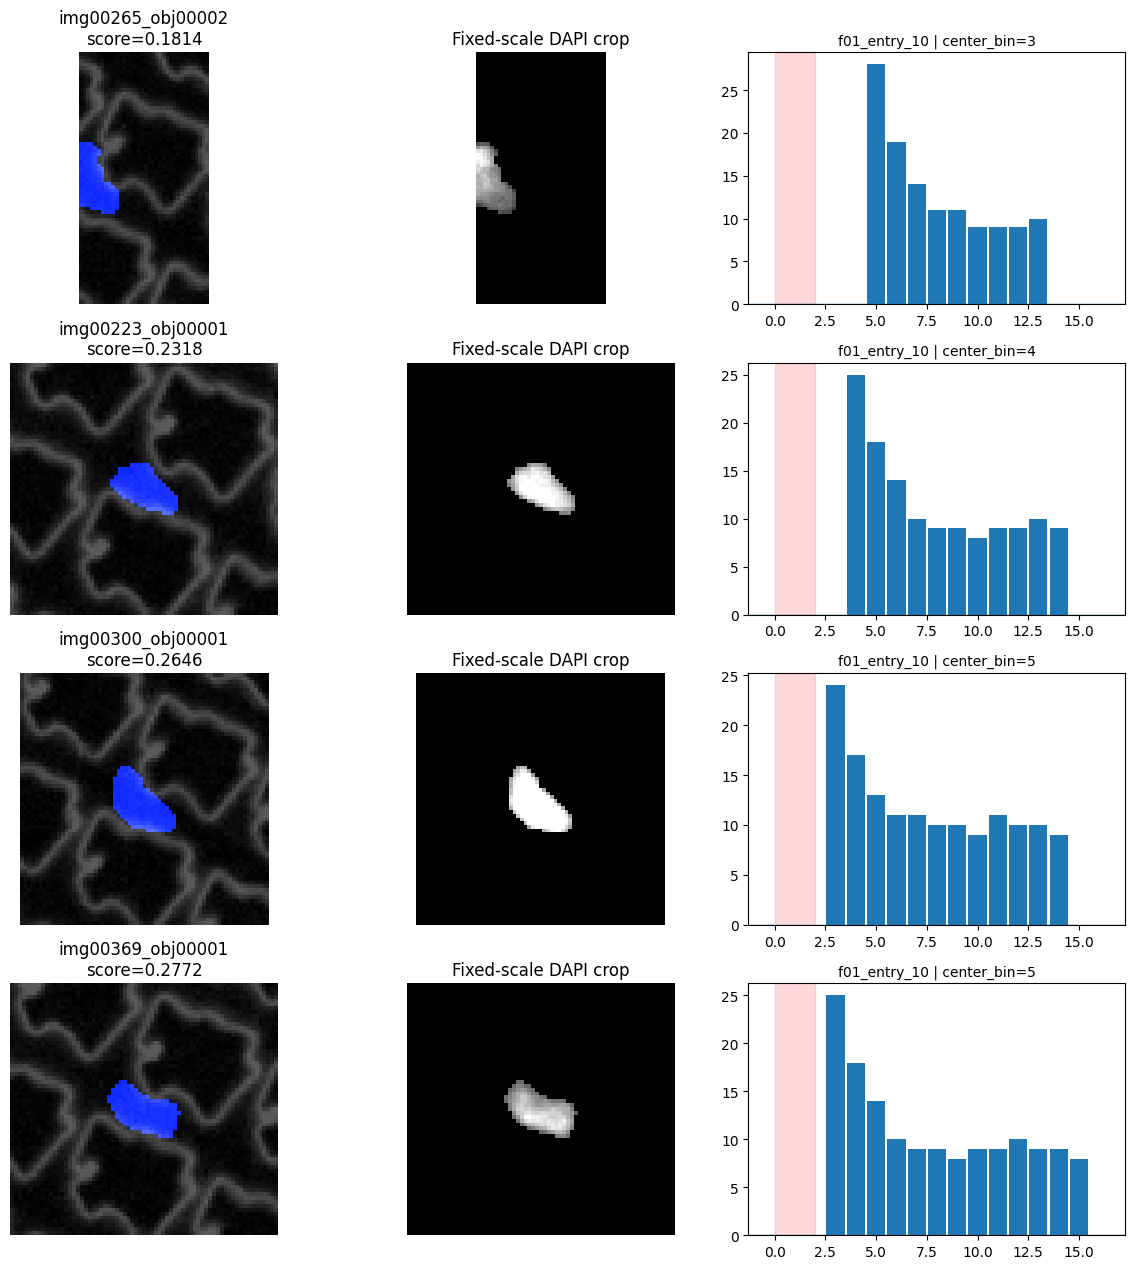

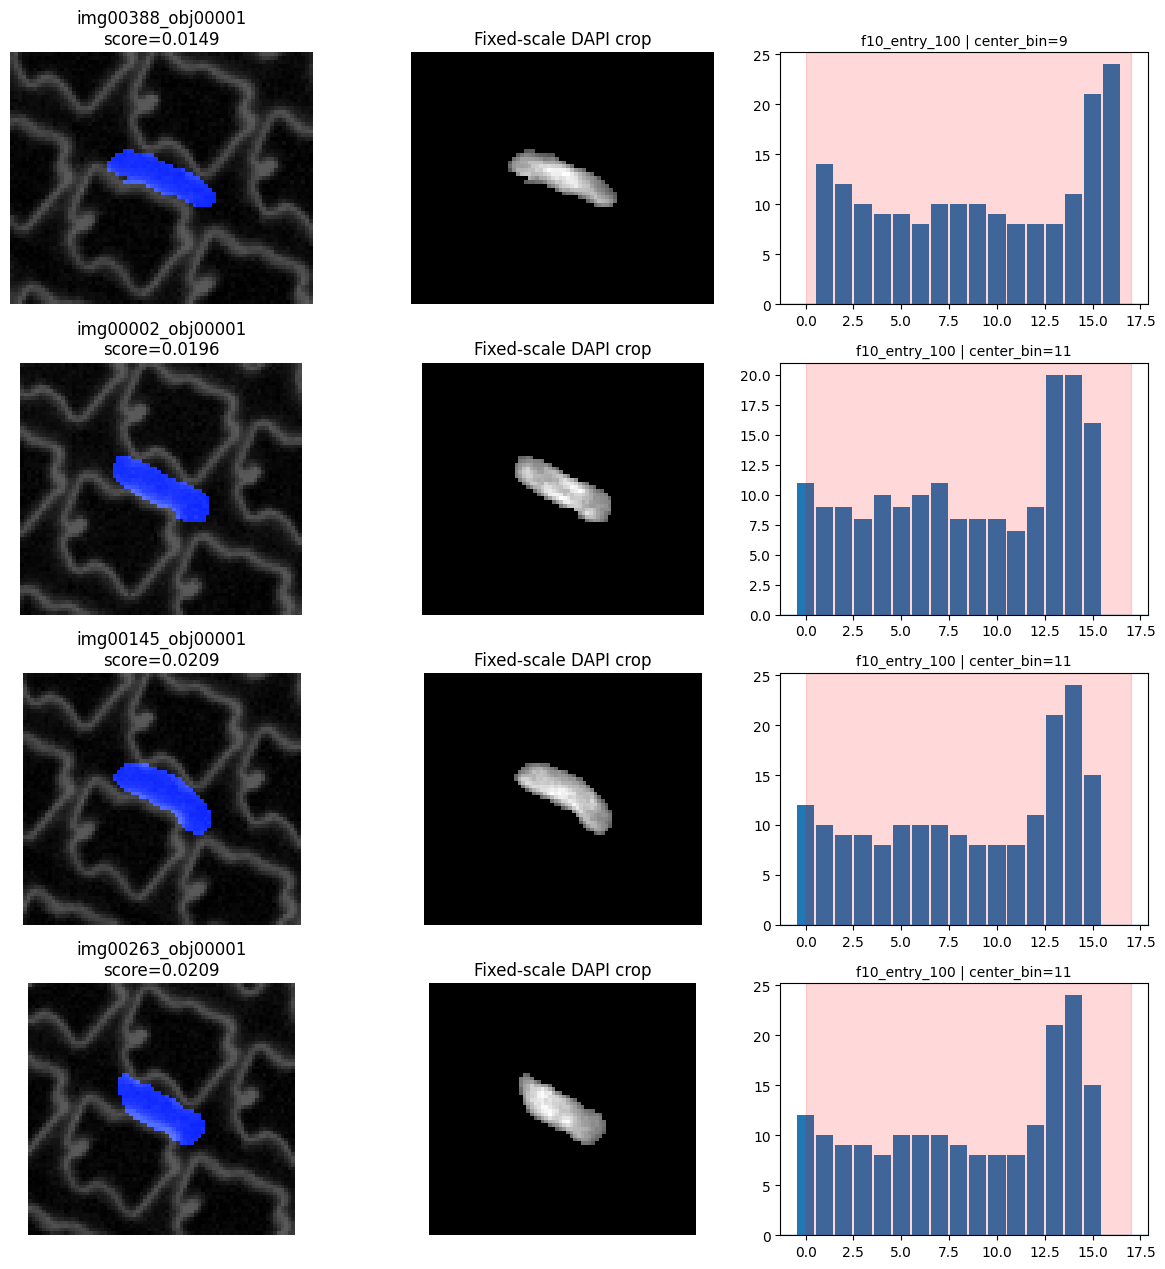

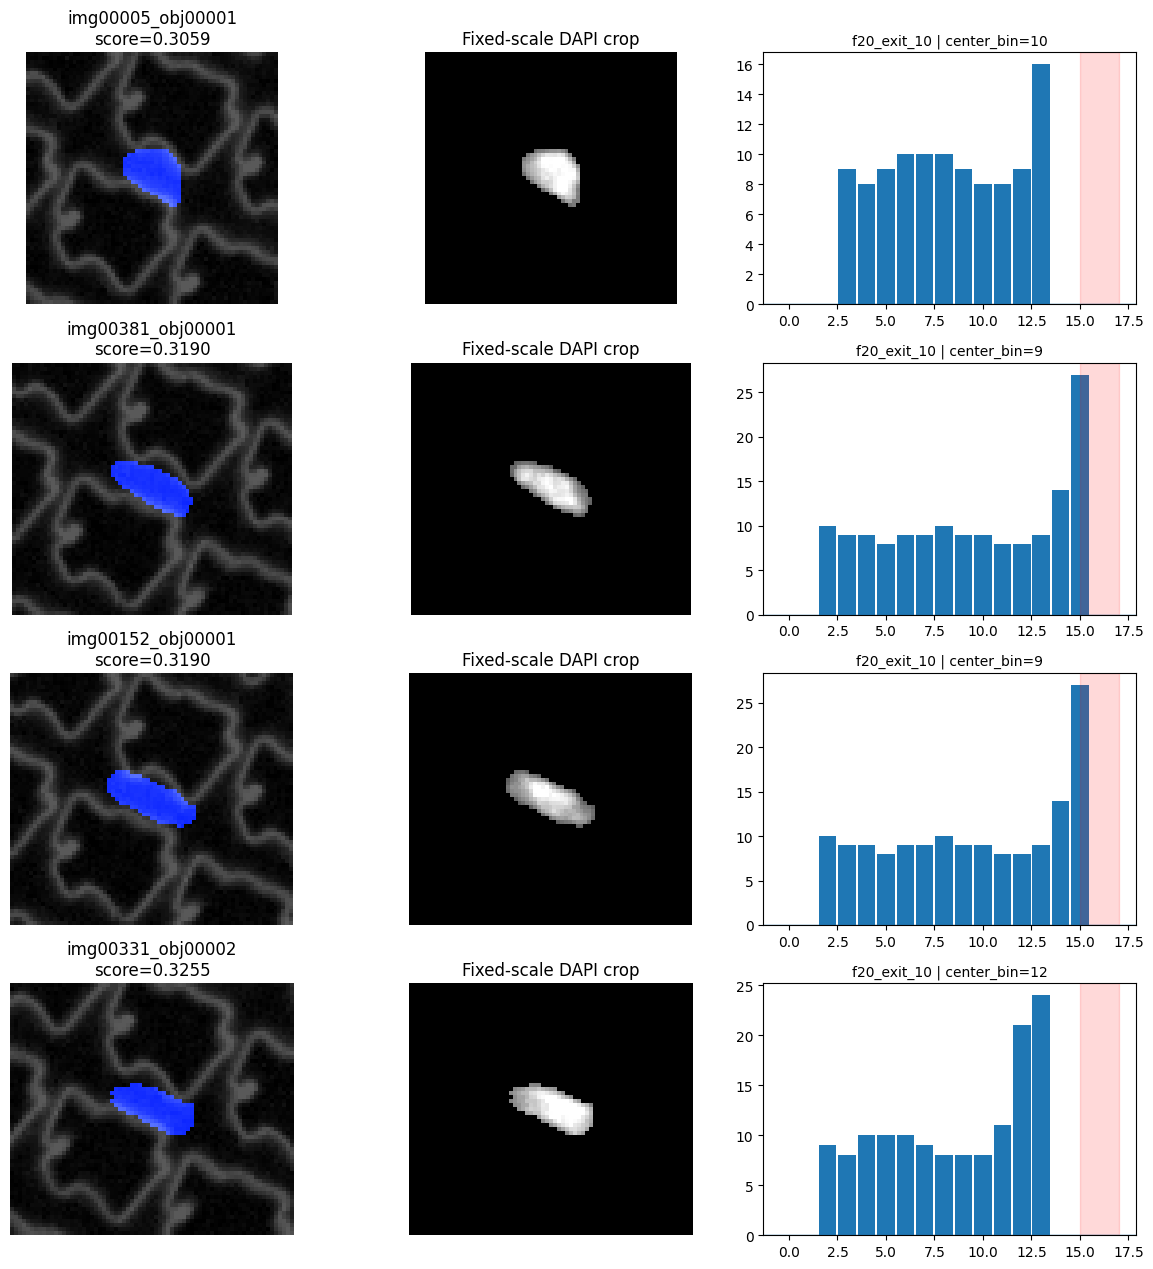

In [7]:

# Example preview:
preview_frame_candidates("f01_entry_10", n=4)
preview_frame_candidates("f10_entry_100", n=4)
preview_frame_candidates("f20_exit_10", n=4)


In [8]:

# ----------------------------
# EXPORT HELPERS
# ----------------------------
def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def export_single_candidate_png(row_idx, frame_name, out_path, score):
    pack = build_candidate_preview(row_idx, frame_name)
    row = pack["row"]
    spec = pack["spec"]

    fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))

    axes[0].imshow(pack["overlay_crop"])
    axes[0].set_title(f"{frame_name}\n{row['unique_key']}\nscore={score:.4f}")
    axes[0].axis("off")

    axes[1].imshow(pack["dapi_crop"], cmap="gray")
    axes[1].set_title("Fixed-scale DAPI crop")
    axes[1].axis("off")

    plot_centered_profile(
        axes[2],
        row["centered_profile"],
        spec,
        title=f"center_bin={row['pt_center_bin_num']}"
    )

    plt.tight_layout()
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.close(fig)


def export_contact_sheet(frame_name, frame_df, out_path, rows_per_page=10):
    n = len(frame_df)
    nrows = min(rows_per_page, n)

    fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(12, 3.1 * nrows))
    if nrows == 1:
        axes = np.array([axes])

    for ax_row in axes:
        for ax in ax_row:
            ax.axis("off")

    for r, (_, cand) in enumerate(frame_df.head(rows_per_page).iterrows()):
        row_idx = int(cand["row_idx"])
        pack = build_candidate_preview(row_idx, frame_name)
        row = pack["row"]
        spec = pack["spec"]

        axes[r, 0].imshow(pack["overlay_crop"])
        axes[r, 0].set_title(f"{row['unique_key']} | score={cand['score']:.4f}")
        axes[r, 0].axis("off")

        plot_centered_profile(
            axes[r, 1],
            row["centered_profile"],
            spec,
            title=f"{frame_name} | center_bin={row['pt_center_bin_num']}"
        )

    plt.tight_layout()
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.close(fig)


def export_frame_groups(candidates_df, out_dir, top_k_per_frame=50, rows_per_contact_sheet=10):
    out_dir = ensure_dir(out_dir)

    manifest_all = []
    summary_rows = []

    for spec in FRAME_TEMPLATES:
        frame_name = spec["frame_name"]
        frame_dir = ensure_dir(out_dir / frame_name)

        sub = (
            candidates_df.loc[candidates_df["frame_name"] == frame_name]
            .sort_values("score", ascending=True)
            .copy()
        )

        if top_k_per_frame is not None:
            sub = sub.head(top_k_per_frame).copy()

        exported_rows = []
        export_rank = 0

        for _, cand in sub.iterrows():
            row_idx = int(cand["row_idx"])
            row = df.loc[row_idx]

            try:
                # quick file validation before export
                _ = to_2d(read_image(row[BG_COL]))
                _ = to_2d(read_image(row[DAPI_COL]))

                export_rank += 1
                png_name = f"candidate_{export_rank:04d}_{row['unique_key']}.png"
                png_path = frame_dir / png_name

                export_single_candidate_png(
                    row_idx=row_idx,
                    frame_name=frame_name,
                    out_path=png_path,
                    score=float(cand["score"])
                )

                record = {
                    "frame_name": frame_name,
                    "export_rank": export_rank,
                    "row_idx": row_idx,
                    "unique_key": row["unique_key"],
                    BG_COL: row[BG_COL],
                    DAPI_COL: row[DAPI_COL],
                    PT_CENTER_COL: row["pt_center_bin_num"],
                    "score": float(cand["score"]),
                    "emd_like": float(cand["emd_like"]),
                    "com_dist": float(cand["com_dist"]),
                    "l2_dist": float(cand["l2_dist"]),
                    "png_name": png_name,
                    "selected": 0,
                }
                exported_rows.append(record)
                manifest_all.append(record)

            except Exception as e:
                exported_rows.append({
                    "frame_name": frame_name,
                    "export_rank": np.nan,
                    "row_idx": row_idx,
                    "unique_key": row["unique_key"],
                    "score": float(cand["score"]),
                    "error": str(e),
                    "selected": 0,
                })

        frame_manifest = pd.DataFrame(exported_rows)
        frame_manifest.to_csv(frame_dir / "metadata.csv", index=False)

        successful = frame_manifest["png_name"].notna().sum() if "png_name" in frame_manifest.columns else 0

        if successful > 0:
            contact_path = frame_dir / "contact_sheet_001.png"
            ok_rows = frame_manifest.loc[frame_manifest["png_name"].notna()].copy()
            ok_rows = ok_rows.merge(
                sub[["row_idx", "score"]].drop_duplicates(),
                on=["row_idx", "score"],
                how="left"
            )
            export_contact_sheet(frame_name, ok_rows, contact_path, rows_per_page=rows_per_contact_sheet)

        summary_rows.append({
            "frame_name": frame_name,
            "n_scored": int((candidates_df["frame_name"] == frame_name).sum()),
            "n_exported": int(successful),
            "top_k_limit": top_k_per_frame if top_k_per_frame is not None else "all",
        })

    pd.DataFrame(summary_rows).to_csv(out_dir / "summary_counts.csv", index=False)
    pd.DataFrame(manifest_all).to_csv(out_dir / "summary_best_candidates.csv", index=False)

    print(f"Export finished: {out_dir}")


In [9]:

# ----------------------------
# RUN EXPORT
# ----------------------------
OUT_DIR.mkdir(parents=True, exist_ok=True)

export_frame_groups(
    candidates_df=candidates,
    out_dir=OUT_DIR,
    top_k_per_frame=TOP_K_PER_FRAME,
    rows_per_contact_sheet=ROWS_PER_CONTACT_SHEET
)


Export finished: frame_candidate_search_output


In [10]:
# ----------------------------
# BUILD ONE AUTOMATIC 20-FRAME SEQUENCE
# ----------------------------
FRAME_ORDER = [spec["frame_name"] for spec in FRAME_TEMPLATES]


def select_unique_greedy_sequence(candidates_df, frame_order):
    """
    Greedy selector:
    for each frame in order, take the best-scoring candidate
    whose unique_key has not been used yet.
    """
    selected_rows = []
    used_keys = set()

    for frame_name in frame_order:
        sub = (
            candidates_df.loc[candidates_df["frame_name"] == frame_name]
            .sort_values(["score", "rank_within_frame"], ascending=[True, True])
            .copy()
        )

        chosen = None
        for _, r in sub.iterrows():
            if r["unique_key"] not in used_keys:
                chosen = r
                break

        if chosen is None:
            print(f"WARNING: no unused candidate found for {frame_name}")
            continue

        selected_rows.append(chosen)
        used_keys.add(chosen["unique_key"])

    seq = pd.DataFrame(selected_rows).reset_index(drop=True)
    return seq


sequence_auto = select_unique_greedy_sequence(candidates, FRAME_ORDER)

display(sequence_auto[[
    "frame_idx", "frame_name", "unique_key", "score", "pseudotime_center_bin"
]])
print("Frames selected:", len(sequence_auto))
print("Unique objects used:", sequence_auto["unique_key"].nunique())

,frame_idx,frame_name,unique_key,score,pseudotime_center_bin
0,1,f01_entry_10,img00265_obj00002,0.181423,3
1,2,f02_entry_20,img00223_obj00001,0.171796,4
2,3,f03_entry_30,img00300_obj00001,0.155772,5
3,4,f04_entry_40,img00369_obj00001,0.125243,5
4,5,f05_entry_50,img00242_obj00001,0.087664,6
5,6,f06_entry_60,img00220_obj00001,0.054567,5
6,7,f07_entry_70,img00216_obj00001,0.037202,6
7,8,f08_entry_80,img00315_obj00001,0.034189,6
8,9,f09_entry_90,img00307_obj00001,0.019584,7
9,10,f10_entry_100,img00388_obj00001,0.014918,9


Frames selected: 20
Unique objects used: 20



## Notes for the next phase

This notebook creates **candidate pools** only.

It does **not** yet:
- enforce one-object-only usage across the final sequence
- rank a full 20-frame sequence jointly
- use `cp_measure` morphology similarity across frame groups
- assemble the final GIF

Those belong in the next notebook or next section:
1. manual selection
2. semi-automated full-sequence matching
3. final GIF export


In [30]:
import imageio.v2 as imageio


GIF_DIR = OUT_DIR / "gif_build"
GIF_DIR.mkdir(parents=True, exist_ok=True)

GIF_FRAME_SIZE = (900, 320)   # (width, height)
GIF_FPS = 0.005
GIF_HOLD_LAST_N = 4           # repeat last frame a few times


def pad_to_canvas(img, out_w, out_h, bg_value=255):
    """
    Center an RGB or grayscale image on a fixed canvas.
    """
    arr = np.asarray(img)

    if arr.ndim == 2:
        canvas = np.full((out_h, out_w), bg_value, dtype=arr.dtype)
    else:
        canvas = np.full((out_h, out_w, arr.shape[2]), bg_value, dtype=arr.dtype)

    h, w = arr.shape[:2]

    scale = min(out_w / w, out_h / h)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    pil = Image.fromarray(arr)
    pil = pil.resize((new_w, new_h), resample=Image.BILINEAR)
    arr2 = np.asarray(pil)

    y0 = (out_h - new_h) // 2
    x0 = (out_w - new_w) // 2
    canvas[y0:y0+new_h, x0:x0+new_w] = arr2
    return canvas


def render_sequence_frame(row, out_path=None):
    """
    Render one final GIF frame from the chosen candidate.
    Uses the same preview layout:
    overlay crop | fixed-scale DAPI | centered profile
    """
    pack = build_candidate_preview(int(row["row_idx"]), row["frame_name"])
    spec = pack["spec"]
    meta_row = pack["row"]

    fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))

    axes[0].imshow(pack["overlay_crop"])
    axes[0].set_title(f"{row['frame_name']}\n{meta_row['unique_key']}\nscore={row['score']:.4f}")
    axes[0].axis("off")

    axes[1].imshow(pack["dapi_crop"], cmap="gray")
    axes[1].set_title("Fixed-scale DAPI crop")
    axes[1].axis("off")

    plot_centered_profile(
        axes[2],
        meta_row["centered_profile"],
        spec,
        title=f"center_bin={meta_row['pt_center_bin_num']}"
    )

    plt.tight_layout()

    tmp_path = GIF_DIR / "_tmp_frame.png"
    fig.savefig(tmp_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    arr = imageio.imread(tmp_path)
    arr = pad_to_canvas(arr, GIF_FRAME_SIZE[0], GIF_FRAME_SIZE[1], bg_value=255)

    if out_path is not None:
        imageio.imwrite(out_path, arr)

    return arr

In [31]:
from PIL import Image
# Render individual PNG frames + collect for GIF
gif_frames = []

for _, row in sequence_auto.sort_values("frame_idx").iterrows():
    out_png = GIF_DIR / f"{int(row['frame_idx']):02d}_{row['frame_name']}.png"
    frame_arr = render_sequence_frame(row, out_path=out_png)
    gif_frames.append(frame_arr)

# hold on the last frame a bit
for _ in range(GIF_HOLD_LAST_N):
    gif_frames.append(gif_frames[-1])

gif_path = GIF_DIR / "animation_auto.gif"
imageio.mimsave(gif_path, gif_frames, duration=1.0 / GIF_FPS, loop=0)

print("Saved GIF to:", gif_path)
gif_path

Saved GIF to: frame_candidate_search_output\gif_build\animation_auto.gif


WindowsPath('frame_candidate_search_output/gif_build/animation_auto.gif')

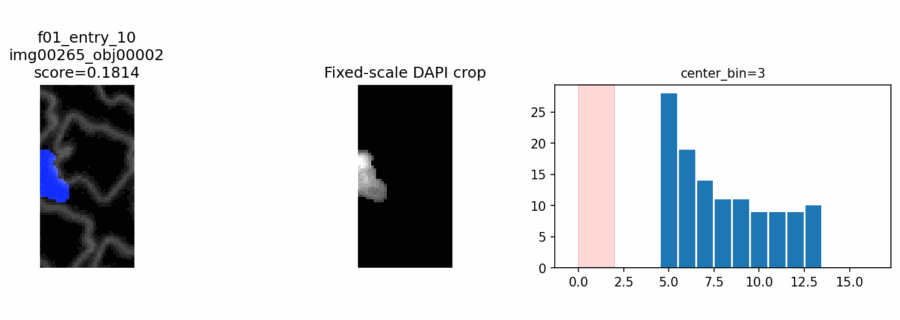

In [32]:
from IPython.display import Image as IPyImage, display

display(IPyImage(filename=str(gif_path)))